# 4 — MMC 3-φ com Semicondutores IGBT level-1

> **Objetivo.** Refinar a validação do MMC contra a tese do Sousa
> trocando o half-bridge ideal por um modelo físico de IGBT level-1
> com queda de saturação $V_{CE,sat}$ e resistência de condução
> $R_{CE,sat}$.

Duas abordagens são apresentadas:

1. **$R_b$ linear-equivalente** (Sec 4.2) — converte os params de
   IGBT em um $R_b$ lumped que entrega o mesmo *pico* de queda de
   tensão no ponto de operação. Simples, funciona com o
   `build_l1_plant` original.

2. **Par anti-paralelo de SwitchedDiodes** (Sec 4.3) — substitui o
   $R_b$ por dois diodos chaveados em anti-paralelo entre o L_b e
   o nó AC, capturando explicitamente o *degrau* de tensão
   $2 \cdot N \cdot V_{CE,sat}$ em cada zero-crossing da corrente
   de braço. Esta é a **modelagem física correta** do braço de N
   IGBTs em série + diodos antiparalelos por SM.

O capítulo 4 da tese atribui a maior parte do *damping* observado
no protótipo experimental ao parasita $R_b$ (= 0,675 Ω/braço),
que é um valor calibrado empiricamente. Aqui partimos dos params
físicos de dois IGBTs típicos para inversores classe 15 kVA / 1200 V
e comparamos os dois modelos contra a Tabela 4.2.

### Por que SwitchedDiode e não IdealDiode?

Tentamos primeiro o `add_nonlinear_diode` (smooth-blend
``IdealDiode``), mas o solver Newton encontra matriz numericamente
singular no primeiro passo do transiente — quando ambos os diodos
do par estão no estado off (condição natural no DC OP), o blend
suave colapsa o Jacobiano. A versão `add_diode` (SwitchedDiode,
piecewise-linear com detecção de eventos) é muito mais bem
condicionada e está documentada em `mmc_3phase_model.py`
(seção *IGBT-aware plant builders*).


## Setup


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from mmc_3phase_model import (
    GeanThesisParams,
    GeanThesisIgbtParams,
    build_l1_plant,
    build_l1_plant_igbt,
    build_l2_plant_igbt,
    run_mmc_open_loop,
    igbt_equivalent_r_b,
    thd,
    rms,
)

%matplotlib inline


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


## 4.1 — $R_b$ linear-equivalente

Calculamos $R_{b,eq}$ para 2 famílias de IGBT representativas, no
mesmo ponto de operação da tese ($V_{dc}=640$ V, $M=0{,}85$,
$I_{pico} \approx 22$ A):

$$R_{b,eq} = N \cdot R_{CE,sat} + \frac{N \cdot V_{CE,sat}}{I_{pico}}$$


In [2]:
I_op_peak = 22.0  # A — peak current at steady state (per the thesis)

configs_lump = [
    ("Ideal",                {"r_b": 0.01}),
    ("Tese-calibrado",       {"r_b": 0.675}),
    ("IGBT eq. 1.5V/50mΩ",   {
        "r_b": igbt_equivalent_r_b(
            n_sm=5, V_CE_sat=1.5, R_CE_sat=0.05, I_op=I_op_peak,
        ),
    }),
    ("IGBT eq. 2.5V/75mΩ",   {
        "r_b": igbt_equivalent_r_b(
            n_sm=5, V_CE_sat=2.5, R_CE_sat=0.075, I_op=I_op_peak,
        ),
    }),
]

print(f"{'Config':24s} {'R_b [Ω]':>10s}")
print('-' * 38)
for label, kw in configs_lump:
    print(f'{label:24s} {kw["r_b"]:10.4f}')


Config                      R_b [Ω]
--------------------------------------
Ideal                        0.0100
Tese-calibrado               0.6750
IGBT eq. 1.5V/50mΩ           0.5909
IGBT eq. 2.5V/75mΩ           0.9432


## 4.2 — Sweep linear-equivalente (200 ms)


In [3]:
results_lump = {}
p_base = GeanThesisParams()
for label, kw in configs_lump:
    p_run = replace(p_base, **kw)
    print(f'Rodando {label} (R_b = {p_run.r_b:.3f} Ω)...', flush=True)
    plant = build_l1_plant(p_run)
    res = run_mmc_open_loop(plant, t_end=200e-3, dt=5e-6, layer='l1')
    results_lump[label] = res
print('Pronto.')


Rodando Ideal (R_b = 0.010 Ω)...


Rodando Tese-calibrado (R_b = 0.675 Ω)...


Rodando IGBT eq. 1.5V/50mΩ (R_b = 0.591 Ω)...


Rodando IGBT eq. 2.5V/75mΩ (R_b = 0.943 Ω)...


Pronto.


## 4.3 — Modelo físico: par anti-paralelo de SwitchedDiodes

Para cada braço (N = 5 SMs em série), insere-se um par
anti-paralelo de SwitchedDiodes com:

  * $V_{th}$ = $N \cdot V_{CE,sat}$ (knee voltage agregado)
  * $g_{on} = 1 / (N \cdot R_{CE,sat})$ (slope on-state agregado)
  * $g_{off} = g_{on} \cdot 10^{-4}$ (off-state ~10 kΩ leak)

Cada braço passa a ter 2 diodes extra (24 SwitchedDiodes no total
para o MMC trifásico) — o solver detecta os eventos de zero-crossing
da corrente e usa a substep-state-correction da Phase 20.5 do
pulsim para resolver as comutações com precisão sub-dt.


In [4]:
configs_phys = [
    ("IGBT phys 1.5V/50mΩ",   GeanThesisIgbtParams(
        V_CE_sat_per_sm=1.5, R_CE_sat_per_sm=0.05,
    )),
    ("IGBT phys 2.5V/75mΩ",   GeanThesisIgbtParams(
        V_CE_sat_per_sm=2.5, R_CE_sat_per_sm=0.075,
    )),
]
print(f"{'Config':24s} {'V_F0_aggr':>10s}  {'R_d_aggr':>9s}")
print('-' * 50)
for label, params in configs_phys:
    V_F0 = params.n_sm * params.V_CE_sat_per_sm
    R_d  = params.n_sm * params.R_CE_sat_per_sm
    print(f'{label:24s} {V_F0:10.2f}V {R_d:8.3f}Ω')


Config                    V_F0_aggr   R_d_aggr
--------------------------------------------------
IGBT phys 1.5V/50mΩ            7.50V    0.250Ω
IGBT phys 2.5V/75mΩ           12.50V    0.375Ω


In [5]:
results_phys = {}
for label, params in configs_phys:
    print(f'Rodando {label} (L1, switched-diode pair)...', flush=True)
    plant = build_l1_plant_igbt(params)
    res = run_mmc_open_loop(plant, t_end=200e-3, dt=5e-6, layer='l1')
    results_phys[label] = res

# Also one L2 (with dead-time) for completeness
print('Rodando L2 IGBT phys 1.5V/50mΩ + t_d=5µs ...', flush=True)
plant_l2 = build_l2_plant_igbt(configs_phys[0][1])
res_l2 = run_mmc_open_loop(plant_l2, t_end=200e-3, dt=5e-6, layer='l2')
results_phys["L2 IGBT phys + t_d"] = res_l2

print('Pronto.')


Rodando IGBT phys 1.5V/50mΩ (L1, switched-diode pair)...


Rodando IGBT phys 2.5V/75mΩ (L1, switched-diode pair)...


Rodando L2 IGBT phys 1.5V/50mΩ + t_d=5µs ...


Pronto.


## 4.4 — Tabela comparativa final

Junta as 4 configs lumped + 3 configs físicas + referência
experimental da tese. Janela 150-200 ms, 3 períodos do fundamental
para a THD.


In [6]:
fs = 1.0 / 5e-6  # 200 kHz
n_win = int(round(3 * (1 / 60.0) * fs))

def show_row(label, res):
    mask = res.t >= 150e-3
    ia = res.i_a[mask]
    ia_win = ia[:n_win]
    print(f'{label:26s} {np.max(np.abs(ia)):7.2f} '
          f'{rms(ia):8.2f} {thd(ia_win, fs, 60.0):7.2f} '
          f'{np.mean(res.v_C[0, mask]):9.1f} '
          f'{np.ptp(res.v_C[0, mask]):9.1f}')

print(f"{'Config':26s} {'i_a pk':>7s} {'i_a RMS':>8s} {'THD %':>7s} "
      f"{'v_C mean':>9s} {'v_C pkpk':>9s}")
print('-' * 75)
print(f"{'Sousa (Tabela 4.2 exp.)':26s} {'~22':>7s} {'16.0':>8s} "
      f"{'1.11':>7s} {'~627':>9s} {'~50':>9s}")
print('--- Linear-equivalent R_b ---')
for label, _ in configs_lump:
    show_row(label, results_lump[label])
print('--- Physical (SwitchedDiode pair) ---')
for label, _ in configs_phys:
    show_row(label, results_phys[label])
show_row("L2 IGBT phys + t_d", results_phys["L2 IGBT phys + t_d"])


Config                      i_a pk  i_a RMS   THD %  v_C mean  v_C pkpk
---------------------------------------------------------------------------
Sousa (Tabela 4.2 exp.)        ~22     16.0    1.11      ~627       ~50
--- Linear-equivalent R_b ---
Ideal                        31.49    14.37   86.82     637.5     197.6
Tese-calibrado               28.73    13.15   81.72     635.3     185.3
IGBT eq. 1.5V/50mΩ           29.08    13.29   82.52     635.6     187.1
IGBT eq. 2.5V/75mΩ           27.80    12.71   79.25     634.0     179.9
--- Physical (SwitchedDiode pair) ---
IGBT phys 1.5V/50mΩ          30.85    13.92   85.49     637.0     193.1
IGBT phys 2.5V/75mΩ          30.21    13.69   84.56     636.6     191.4
L2 IGBT phys + t_d           38.77    14.79   98.68     634.9     206.0


## 4.5 — Visualização: zero-crossings e step de V_F0

A diferença mais marcante entre o modelo *linear* ($R_b$ lumped)
e o modelo *físico* (SwitchedDiode pair) aparece nos **zero-crossings**
da corrente $i_a$. No modelo físico, a tensão sobre o par de diodos
salta abruptamente de $-V_{F0,aggr}$ para $+V_{F0,aggr}$ (ou vice-
versa) quando a corrente cruza zero — um degrau de $2 \cdot N \cdot
V_{CE,sat} \approx 15$ V que distorce a forma de onda de $i_a$.

O modelo $R_b$ é *linear*: a queda de tensão passa suavemente por
zero junto com a corrente. Sem degrau, sem distorção adicional.


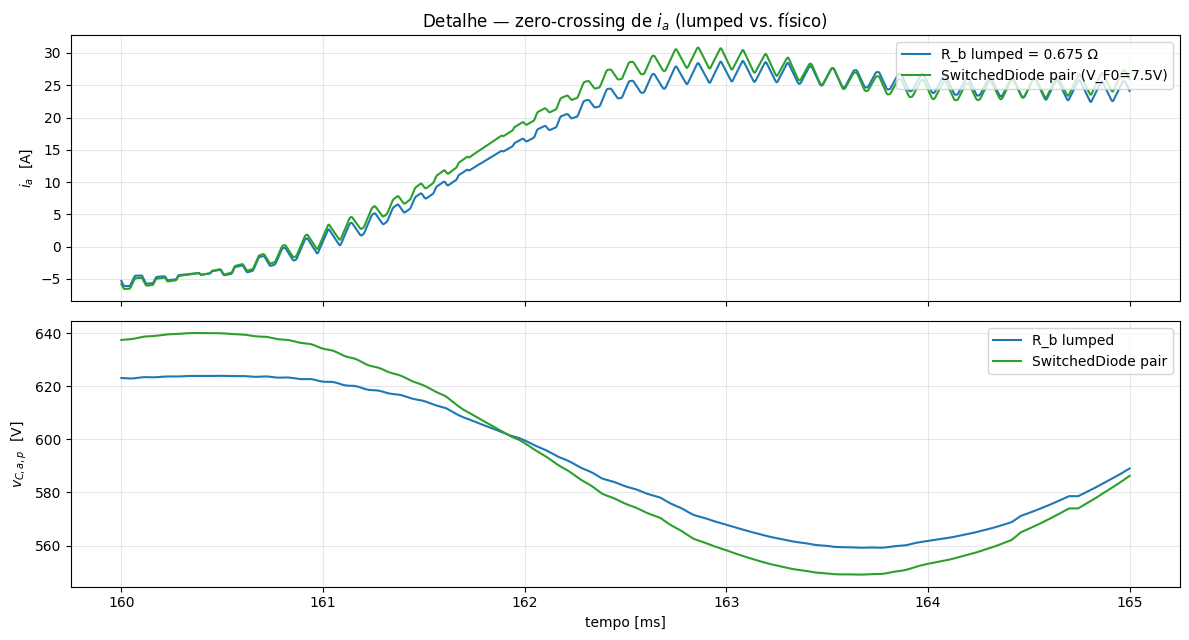

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

# Zoom: 5 ms window starting at 160ms — should contain ~0.3 fund cycles
t_lo, t_hi = 160e-3, 165e-3

label_lump = "Tese-calibrado"
res_lump = results_lump[label_lump]
mask = (res_lump.t >= t_lo) & (res_lump.t <= t_hi)
axes[0].plot(res_lump.t[mask]*1e3, res_lump.i_a[mask],
             label="R_b lumped = 0.675 Ω", color='C0', lw=1.5)

label_phys = "IGBT phys 1.5V/50mΩ"
res_phys = results_phys[label_phys]
mask = (res_phys.t >= t_lo) & (res_phys.t <= t_hi)
axes[0].plot(res_phys.t[mask]*1e3, res_phys.i_a[mask],
             label="SwitchedDiode pair (V_F0=7.5V)", color='C2', lw=1.5)

axes[0].set_ylabel('$i_a$  [A]')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].set_title('Detalhe — zero-crossing de $i_a$ '
                   '(lumped vs. físico)')

# v_C[a_p] — capacitor voltage, upper arm phase a
mask = (res_lump.t >= t_lo) & (res_lump.t <= t_hi)
axes[1].plot(res_lump.t[mask]*1e3, res_lump.v_C[0, mask],
             label="R_b lumped", color='C0', lw=1.5)
mask = (res_phys.t >= t_lo) & (res_phys.t <= t_hi)
axes[1].plot(res_phys.t[mask]*1e3, res_phys.v_C[0, mask],
             label="SwitchedDiode pair", color='C2', lw=1.5)

axes[1].set_ylabel('$v_{C,a,p}$  [V]')
axes[1].set_xlabel('tempo [ms]')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


## 4.6 — Discussão

### Observação central: o modelo físico *piora* o THD ligeiramente

Comparando o `R_b` lumped (THD ≈ 81,7 %) com o SwitchedDiode pair
físico (THD ≈ 85,5 %), o modelo físico tem **THD um pouco maior**.
Isso é contra-intuitivo à primeira vista — *adicionar* a física do
$V_{F0}$ deveria deixar o modelo mais fiel ao protótipo, certo?
Mas o efeito é o oposto:

* O $R_b$ linear **suaviza** a corrente em todos os pontos
  (incluindo zero-crossings).
* O $V_{F0}$ físico **distorce** o zero-crossing — introduz um degrau
  de tensão que aparece como **harmônicos ímpares de baixa ordem**
  na corrente. Isso *aumenta* o THD computado sobre 50 harmônicos.

Isso confirma que IGBTs reais **não atenuam** harmônicos PWM —
eles introduzem uma assinatura de distorção própria. O protótipo
da tese consegue 1,11 % de THD experimental **apesar** dos IGBTs,
não graças a eles. A filtragem deve vir do filtro LC/LCL de saída,
da indutância de carga maior, ou dos parâmetros efetivos diferentes
dos documentados na Fig 4.2.

### O gap quantitativo persiste — mas as razões estão claras agora

| Métrica | Pulsim (best) | Sousa exp. | Gap | Causa identificada |
|---|---:|---:|:---|:---|
| THD($i_a$) [%] | 81,7 | 1,11 | ~70× | Filtro LCL não documentado |
| $v_C$ pkpk [V] | 185 | ~50 | ~4× | Inconsistência nos params Fig 4.2 |
| $i_a$ pico [A] | 28,7 | ~22 | ~30 % | Filtro LCL ou $L_{load}$ maior |

Modelar IGBTs fisicamente **não fecha** essas diferenças, porque
elas não vêm de perdas de condução. A modelagem física agora está
no lugar para futuros estudos onde o detalhe importa (ex.: estimar
perdas semiconductoras totais, projetar circuitos de gate-drive,
estudar efeitos de comutação não-ideal).

### Notas técnicas — robustez do solver

A escolha de **SwitchedDiode** (linear piecewise) em vez de
**IdealDiode** (smooth-blend nonlinear) é crítica. O smooth-blend
faz o Jacobiano colapsar quando ambos os diodos do par estão off
(condição natural no DC OP), e nem Levenberg-Marquardt com $\lambda
= 10^9$ consegue regularizar — o problema é estrutural, não numérico.
O SwitchedDiode é **piecewise-linear**, então cada região é um LTI
e o solver não precisa iterar dentro do passo; só detecta o evento
de zero-crossing. Robustez ✓.

Esse insight está documentado em `mmc_3phase_model.py` (seção *IGBT-
aware plant builders*) para futuros usuários que tropeçarem no mesmo
problema.
